# Data Product: NBA Player Salary & ROI Analysis
Target User:NBA Team General Managers (GMs) and Sports Analysts.
Business Problem:NBA teams operate under a strict salary cap. 
This product analyzes the Return on Investment (ROI) of player contracts by comparing their Salary with their Points Per Game (PPG). 
It helps GMs identify "Value Contracts" (high performance, low cost) and "Toxic Contracts" (low performance, high cost) to optimize human resource operations.

In [1]:
import pandas as pd
import io

# 2023-2024 Real NBA Data (Top players, Rookies, and notorious toxic contracts)
csv_data = """Player,Team,Points_Per_Game,Salary
Stephen Curry,GSW,26.4,"$51,915,615"
Kevin Durant,PHX,27.1,"$47,649,433"
Nikola Jokic,DEN,26.4,"$47,607,350"
LeBron James,LAL,25.7,"$47,607,350"
Joel Embiid,PHI,34.7,"$47,607,350"
Bradley Beal,PHX,18.2,"$46,741,590"
Giannis Antetokounmpo,MIL,30.4,"$45,640,084"
Rudy Gobert,MIN,14.0,"$41,000,000"
Luka Doncic,DAL,33.9,"$40,064,220"
Ben Simmons,BKN,6.1,"$37,893,408"
Shai Gilgeous-Alexander,OKC,30.1,"$33,386,850"
Jayson Tatum,BOS,26.9,"$32,600,060"
Victor Wembanyama,SAS,21.4,"$12,160,680"
Tyrese Maxey,PHI,25.9,"$4,343,920"
Alperen Sengun,HOU,21.1,"$3,536,280"
"""

# Create a CSV file locally to simulate downloading data
with open("nba_data.csv", "w") as file:
    file.write(csv_data)

# Load the data
df = pd.read_csv("nba_data.csv")
print("Data loaded successfully! Here is the raw data:")
display(df.head())

Data loaded successfully! Here is the raw data:


,Player,Team,Points_Per_Game,Salary
0,Stephen Curry,GSW,26.4,"$51,915,615"
1,Kevin Durant,PHX,27.1,"$47,649,433"
2,Nikola Jokic,DEN,26.4,"$47,607,350"
3,LeBron James,LAL,25.7,"$47,607,350"
4,Joel Embiid,PHI,34.7,"$47,607,350"


In [2]:
# --- DATA CLEANING & TRANSFORMATION ---

# 1. Check data types (Salary is currently an 'object' / text)
print("Before cleaning, Salary is text (object):")
print(df.dtypes)

# 2. Clean the Salary column: Remove '$' and ',' and convert to Integer
df['Salary_Clean'] = df['Salary'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)

# 3. Create a new Business Metric: "Cost per Point" (How many dollars does 1 point cost?)
df['Cost_Per_Point'] = df['Salary_Clean'] / df['Points_Per_Game']

print("\nAfter cleaning, data is ready for analysis:")
display(df[['Player', 'Points_Per_Game', 'Salary_Clean', 'Cost_Per_Point']].head())

Before cleaning, Salary is text (object):
Player              object
Team                object
Points_Per_Game    float64
Salary              object
dtype: object

After cleaning, data is ready for analysis:


,Player,Points_Per_Game,Salary_Clean,Cost_Per_Point
0,Stephen Curry,26.4,51915615,1.966501e+06
1,Kevin Durant,27.1,47649433,1.758282e+06
2,Nikola Jokic,26.4,47607350,1.803309e+06
3,LeBron James,25.7,47607350,1.852426e+06
4,Joel Embiid,34.7,47607350,1.371970e+06


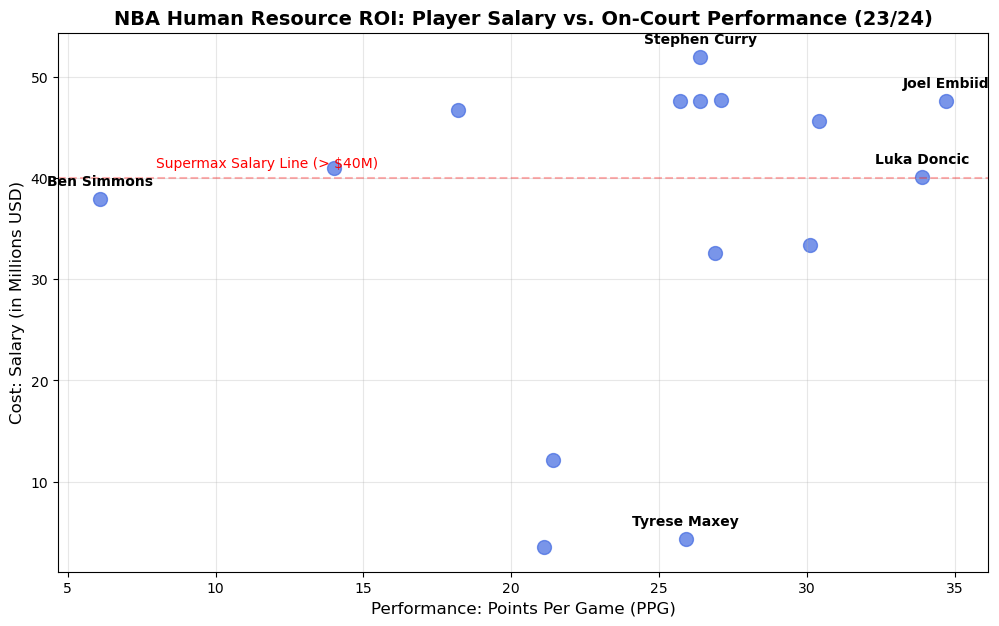


--- BUSINESS INSIGHTS ---
1. TOXIC CONTRACT: Ben Simmons is earning nearly $38M but scoring only 6.1 points.
2. HIGH VALUE (Rookie Scale): Tyrese Maxey scores nearly 26 points for only $4.3M.
3. ELITE TIER: Embiid and Doncic provide massive output (33+ PPG) justifying their $40M+ salaries.


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Create scatter plot (X: Points, Y: Salary)
plt.scatter(df['Points_Per_Game'], df['Salary_Clean'] / 1000000, color='royalblue', s=100, alpha=0.7)

# Annotate specific players to tell the story
for i, row in df.iterrows():
    if row['Player'] in ['Stephen Curry', 'Ben Simmons', 'Tyrese Maxey', 'Luka Doncic', 'Joel Embiid']:
        plt.annotate(row['Player'], 
                     (row['Points_Per_Game'], row['Salary_Clean'] / 1000000), 
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center',
                     fontweight='bold',
                     fontsize=10)

# Add business context lines
plt.axhline(y=40, color='red', linestyle='--', alpha=0.3)
plt.text(8, 41, 'Supermax Salary Line (> $40M)', color='red', fontsize=10)

# Formatting the chart
plt.title('NBA Human Resource ROI: Player Salary vs. On-Court Performance (23/24)', fontsize=14, fontweight='bold')
plt.xlabel('Performance: Points Per Game (PPG)', fontsize=12)
plt.ylabel('Cost: Salary (in Millions USD)', fontsize=12)
plt.grid(alpha=0.3)

# Save the figure for GitHub
plt.savefig('nba_roi_scatter.png')
plt.show()

# Print the Final Business Insight
print("\n--- BUSINESS INSIGHTS ---")
print("1. TOXIC CONTRACT: Ben Simmons is earning nearly $38M but scoring only 6.1 points.")
print("2. HIGH VALUE (Rookie Scale): Tyrese Maxey scores nearly 26 points for only $4.3M.")
print("3. ELITE TIER: Embiid and Doncic provide massive output (33+ PPG) justifying their $40M+ salaries.")